In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [9]:
def inv_calc(start_amount, 
             time_period_years, 
             time_period_months, 
             annual_return_rate, 
             contributions, 
             contribution_timing):
    if contribution_timing not in ('Yearly', 'Monthly'):
        raise ValueError("Wrong Contribution Timing")
    else:
        pot_savings = [start_amount]
        wealth = [start_amount]
        total_time_months = time_period_years*12 + time_period_months
        return_rate_monthly = (1+annual_return_rate/100)**(1/12)
        if contribution_timing == 'Monthly':
            cont_lst = [contributions]*(total_time_months+1)
        elif contribution_timing == 'Yearly':
            cont_lst = [contributions if i % 12 == 0 and i != 0 else 0 for i in range(total_time_months+1)]
        total_time_months = time_period_years*12 + time_period_months
        for i in range (1, total_time_months+1):
            wealth.append(wealth[i-1]*return_rate_monthly + cont_lst[i])
            pot_savings.append(cont_lst[i]+pot_savings[i-1])
    return wealth, pot_savings


In [24]:
def inv_calc_futr(start_amount, 
                  time_period_years, 
                  time_period_months, 
                  annual_return_rate, 
                  contributions, 
                  contribution_timing):
    
    # --- 1. VALIDATION & CALCULATION (Unchanged) ---
    if contribution_timing not in ('Yearly', 'Monthly'):
        raise ValueError("Wrong Contribution Timing")
    
    wealth = [start_amount]
    pot_sav = [start_amount]
    total_time_months = time_period_years * 12 + time_period_months
    
    # Calculate monthly return rate
    return_rate_monthly = (1 + annual_return_rate / 100) ** (1 / 12)
    
    # generate contribution list
    if contribution_timing == 'Monthly':
        cont_lst = [contributions] * (total_time_months + 1)
    elif contribution_timing == 'Yearly':
        cont_lst = [contributions if i % 12 == 0 and i != 0 else 0 for i in range(total_time_months + 1)]
        
    # compound loop
    for i in range(1, total_time_months + 1):
        wealth.append(wealth[i-1] * return_rate_monthly + cont_lst[i])
        pot_sav.append(cont_lst[i] + pot_sav[i-1])

    # --- 2. STYLING & PLOTTING (Updated) ---
    
    # Create figure with a slightly wider aspect ratio
    fig, ax = plt.subplots(figsize=(10, 6))

    # COLORS FROM YOUR CSS
    COLOR_NAVY = '#0a1d36'
    COLOR_MID  = '#2366af'
    COLOR_SKY  = '#d3dff1'
    COLOR_GREY = '#b5c5dc'

    # Plot 1: Total Portfolio Value (The "Hero" line)
    # We use a solid navy line and fill underneath it with the "sky" color
    ax.plot(wealth, color=COLOR_NAVY, linewidth=2.5, label='Projected Value')
    ax.fill_between(range(len(wealth)), wealth, color=COLOR_SKY, alpha=0.4)

    # Plot 2: Contributions (The "Baseline")
    # We use a dashed line to differentiate "money in" vs "money growth"
    ax.plot(pot_sav, color=COLOR_MID, linestyle='--', linewidth=2, label='Total Contributed')

    # --- 3. PROFESSIONAL FORMATTING ---

    # Remove top and right borders (spines) for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Color the remaining spines to match your theme (optional, or keep default black)
    ax.spines['left'].set_color(COLOR_NAVY)
    ax.spines['bottom'].set_color(COLOR_NAVY)

    # Grid: subtle, dotted, and sent to the back
    ax.grid(True, which='major', axis='y', linestyle=':', color=COLOR_GREY, alpha=0.7)
    ax.set_axisbelow(True)

    # Titles and Labels (Using a sans-serif font to match Helvetica/Arial)
    ax.set_title(f"Projected Wealth over {time_period_years} Years, {time_period_months} Months", 
                 fontsize=14, fontweight='bold', color=COLOR_NAVY, pad=20)
    
    ax.set_xlabel("Months Elapsed", fontsize=11, color=COLOR_NAVY, labelpad=10)
    # Removed Y-label text "Value" because the currency sign makes it obvious
    
    # Legend: simple frame, keeping it clean
    ax.legend(loc='upper left', frameon=True, fontsize=10)

    # --- 4. CURRENCY FORMATTING ---
    # This formats the Y-axis to look like currency (e.g. £10,000)
    fmt = '£{x:,.0f}'
    tick = mtick.StrMethodFormatter(fmt)
    ax.yaxis.set_major_formatter(tick)

    # Adjust layout to prevent clipping
    fig.tight_layout()
    
    return fig

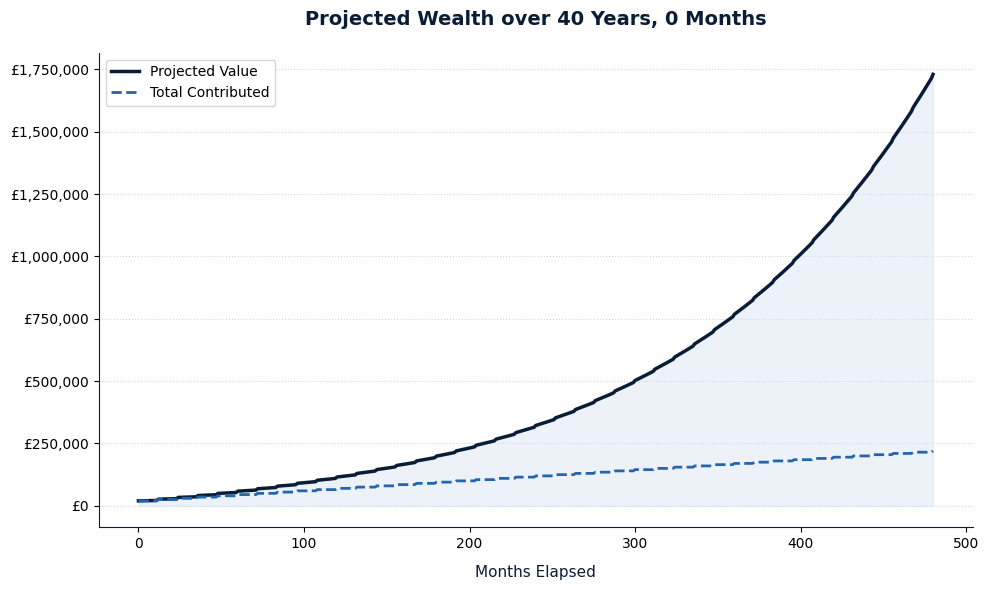

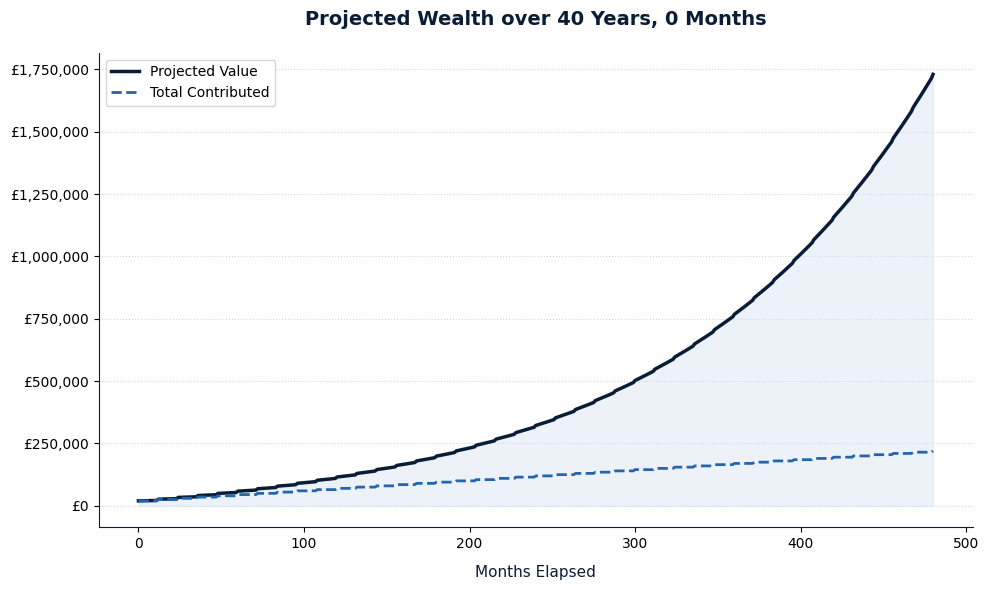

In [25]:
inv_calc_futr(20000, 40, 0, 8, 5000, 'Yearly')